# **Fraunhofer Propagation**

This is a recreation of Chapter 4 - Figure 4.1. The coordinate system for optical wave propagation is as shown:

<div align="center">
  <img src="assets_demo/coordinatesystem.png">
</div>

| Symbol | Meaning |
|---|---|
| $r_1 = (x_1, y_1)$ | Source-plane coordinates |
| $r_2 = (x_2, y_2)$ | Observation-plane coordinates |
| $\delta_1$ | Grid spacing in source plane |
| $\delta_2$ | Grid spacing in observation plane |
| $\Delta z$ | Distance between source and observation plane |

The Fraunhofer diffraction integral is defined as:
\begin{equation}
U(x_2,y_2) = \frac{e^{ik\Delta z}e^{i\frac{k}{2\Delta z}(x_2^2+y_2^2)}}{i\lambda\Delta z}\mathcal{F}\{U(x_1,y_1)\}\big|_ {f_{x_1}=\frac{x_2}{\lambda\Delta z}, f_{y_1}=\frac{y_2}{\lambda\Delta z}}
\end{equation}

Notice that within the Fraunhofer propagation function, the `Uout` computation is missing the $e^{ik\Delta z}$ factor. This is ignored because it is just the on-axis phase. Explain further in Chapter 4. 

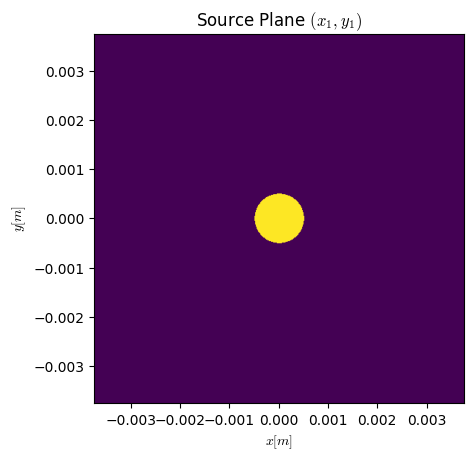

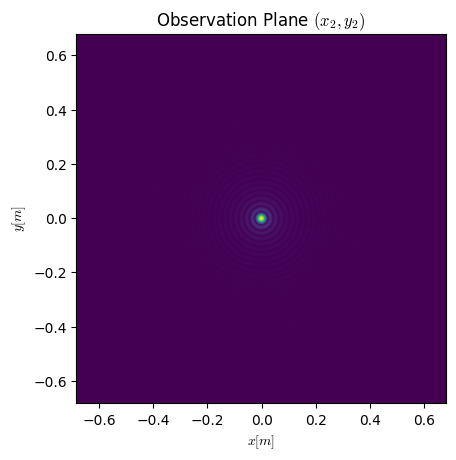

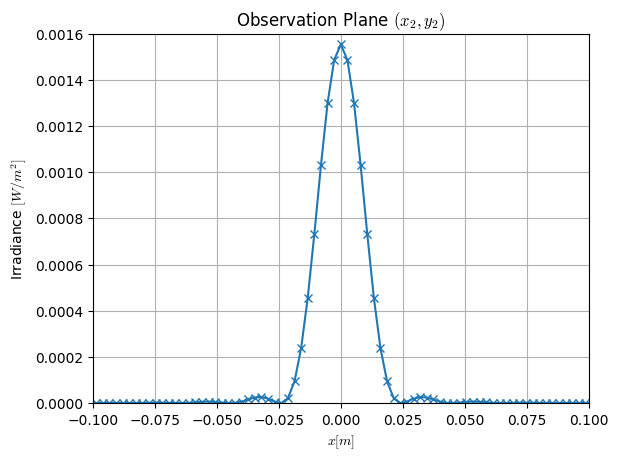

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optprop.aperture_functions import circ
from optprop.prop import fraunhofer_prop

#### Optical geometry properties
N = 512             # Number of sample points
L = 7.5e-3          # Spacial extent of source plane [m]
d1 = L/N            # Sampling interval of source plane [m]
wvl = 1e-6          # Optical wavelength [m]
k = (2*np.pi)/wvl   # Wavenumber
D = 1e-3            # Circular aperture diameter [m]
Dz = 20             # Propagation distance [m]

#### Establish source plane co-ordinates (x1,y1)
x = np.arange(-N/2,N/2,1) * d1
y = x
x1,y1 = np.meshgrid(x,y)

#### Create source field
Uin = circ(x1,y1,D)

#### Fraunhofer propagation of source field to observation (x2,y2)
Uout,x2,y2 = fraunhofer_prop(Uin,wvl,d1,Dz)

#### Plot field intensity at observation plane
fig,ax = plt.subplots()
ax.imshow(Uin,extent=[-L/2,L/2,-L/2,L/2])
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title(r"Source Plane $(x_1,y_1)$",math_fontfamily='cm')

fig,ax = plt.subplots()
ax.imshow(np.abs(Uout),extent=[np.min(x2[0,:]), np.max(x2[0,:]), np.min(y2[:,0]), np.max(y2[:,0])])
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title(r"Observation Plane $(x_2,y_2)$",math_fontfamily='cm')

fig,ax = plt.subplots()
mid_idx = len(Uout)//2
ax.plot(x2[0,:],np.abs(Uout[mid_idx,:]**2),marker='x')
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"Irradiance $[W/m^2]$",math_fontfamily='cm')
ax.set_xlim(-0.1,0.1)
ax.set_ylim(0,1.6e-3)
ax.set_title(r"Observation Plane $(x_2,y_2)$",math_fontfamily='cm')
ax.grid(True,'both')
plt.show()

Note that the y-axis unit differ from the book. The book shows mW instead. 